In [1]:
#/archive dataset from Kaggle: https://www.kaggle.com/datasets/bikashkundu/can-hcrl-otids
#/road dataset: https://zenodo.org/records/10462796

In [1]:
import pandas as pd
import numpy as np
import keras
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from keras import layers
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix


ModuleNotFoundError: No module named 'keras'

In [ ]:
#     DoS Attack (656,579) : Injecting messages of ‘0x000’ CAN ID in a short cycle.
#     Fuzzy Attack (591,990): Injecting messages of spoofed random CAN ID and DATA values.
#     Impersonation Attack (995,472): Injecting messages of Impersonating node, arbitration ID = '0x164'.
#     Attack Free State (2,369,868 ): Normal CAN messages.
   
# 'target' column doesn't specify the attacks, compute and label the values by seeing the above mentioned points 
# for each attacks which are there before applying any model. Impersonation_attacks can be said as spoofing attacks.

balanced_mix = pd.read_csv("archive/CAN_HCRL_OTIDS_B.csv") #CAN_HCRL_OTIDS_B is combined records of all four files and oversampled with SMOTE.(Balanced)
unbalanced_mix = pd.read_csv("archive/CAN_HCRL_OTIDS_UB.csv") #CAN_HCRL_OTIDS_UB is combined records of all four files.(Un-Balanced)
# attack_free = pd.read_csv("archive/dataset.csv") #normal, target column is 0
# dos_attacks = pd.read_csv("archive/dataset1.csv") #dos attack,  target column as 1
# fuzzy_attacks = pd.read_csv("archive/dataset2.csv") #fuzzy attack target column as 2
# impersonation_attacks = pd.read_csv("archive/dataset3.csv") #impersonation attacks, target column as 3. 

In [ ]:
balanced_mix = balanced_mix.fillna(0)
balanced_mix["ID1_int"] = balanced_mix["ID1"].apply(lambda x: int(str(x), 16))
encoder = LabelEncoder()
balanced_mix["ID1"] = encoder.fit_transform(balanced_mix["ID1"].astype(str))

In [ ]:
X_raw = balanced_mix.drop(columns=["target"])
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)
X = np.array(X_scaled).reshape(-1, X_scaled.shape[1], 1)
y = balanced_mix["target"].values

In [ ]:
def create_sequences(X, y, window_size):
    sequences = []
    labels = []
    for i in range(len(X) - window_size):
        sequences.append(X[i:i+window_size])
        labels.append(y[i+window_size])  # label of the last message in the window
    return np.array(sequences), np.array(labels)
# Example: 8 message window
window_size = 8
X_seq, y_seq = create_sequences(X, y, window_size)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( #do a 80-10-10 split
    X_seq, y_seq, test_size=0.2, stratify=y_seq  
)
y_train_cat = to_categorical(y_train) #one-hot encode labels
y_test_cat = to_categorical(y_test)

In [2]:
X_train = X_train.reshape(-1, 8, 11)
print(X_train.shape)


NameError: name 'X_train' is not defined

In [ ]:
#start with 1d cnn sequential model: 
def create_model():
    model = keras.Sequential()
    model.add(layers.Input(shape=(8, 11)))
    model.add(layers.Conv1D(16, 4, activation='relu'))
    model.add(layers.Flatten())
    model.add(layers.Dense(4, activation='softmax'))#output layer will be 4 bc we have 4 potential classifications: normal, DOS attack, Fuzzy Attack, & Impersonation Attack
    return model

model = create_model()

In [14]:
b_size = 32
callbacks = [
    ModelCheckpoint("saved_models/best_model_cnn.keras", monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=1, verbose=1, restore_best_weights=True)
]
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.fit(X_train, y_train_cat, batch_size = b_size, epochs = 3, validation_split=0.1, callbacks = callbacks, verbose = 1)

Epoch 1/3
215306/215316 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7148 - loss: 0.7157
Epoch 1: val_accuracy improved from None to 0.72745, saving model to saved_models/best_model_cnn.keras
215316/215316 ━━━━━━━━━━━━━━━━━━━━ 1614s 7ms/step - accuracy: 0.7216 - loss: 0.6991 - val_accuracy: 0.7274 - val_loss: 0.6885 - learning_rate: 0.0010
Epoch 2/3
215307/215316 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7251 - loss: 0.6897
Epoch 2: val_accuracy did not improve from 0.72745
215316/215316 ━━━━━━━━━━━━━━━━━━━━ 656s 3ms/step - accuracy: 0.7250 - loss: 0.6892 - val_accuracy: 0.7272 - val_loss: 0.6863 - learning_rate: 0.0010
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.


In [ ]:
testing_acc = model.evaluate(X_test,y_test_cat, verbose=1)
print(f"Test loss: {testing_acc[0]}")
print(f"Test accuracy: {testing_acc[1]}")

39874/39874 ━━━━━━━━━━━━━━━━━━━━ 30s 763us/step - accuracy: 0.6962 - loss: 0.7682
Test loss: 0.7681623101234436
Test accuracy: 0.6961966753005981


In [ ]:
#examine classification predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)       
y_true = np.argmax(y_test_cat, axis=1) 
print(classification_report(y_true, y_pred, target_names=["Normal", "DoS", "Fuzzy", "Impersonation"]))

#ROC AUC 
#sensitivity (recall) and 
# validity (precision)
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test_cat, y_pred_probs, multi_class='ovr')
print(f"ROC AUC Score: {roc_auc}")

26583/26583 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step
               precision    recall  f1-score   support

       Normal       0.50      0.88      0.64    212657
          DoS       0.88      0.71      0.79    212658
        Fuzzy       0.90      0.74      0.81    212658
Impersonation       0.97      0.56      0.71    212657

     accuracy                           0.73    850630
    macro avg       0.81      0.73      0.74    850630
 weighted avg       0.81      0.73      0.74    850630



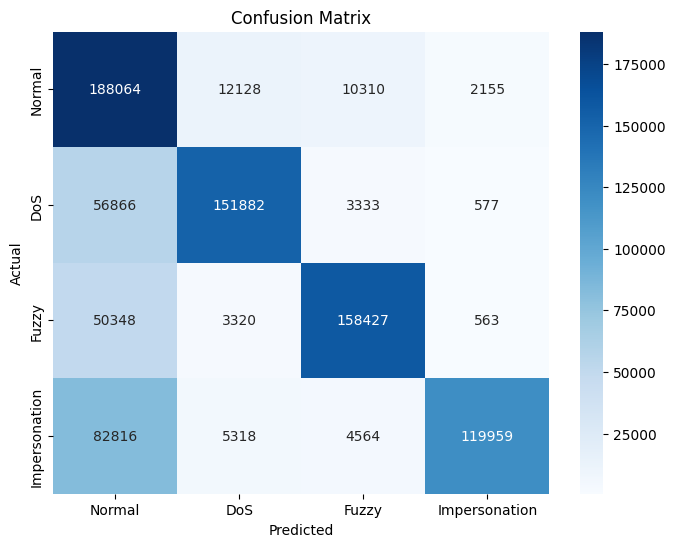

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Normal", "DoS", "Fuzzy", "Impersonation"],
            yticklabels=["Normal", "DoS", "Fuzzy", "Impersonation"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()  